# Quick Analysis for MPC Pendulum Project

This notebook loads saved experiment outputs, builds summary tables, generates report-ready plots, and exports a LaTeX table.


## 1. Imports


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)


## 2. Paths


In [8]:
RESULTS_DIR = Path("../results/raw")
FIGURES_DIR = Path("../results/figures")
TABLES_DIR = Path("../results/tables")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Results dir:", RESULTS_DIR.resolve())
print("JSON files found:", len(list(RESULTS_DIR.glob("*.json"))))


Results dir: /home/ssrivastava/PycharmProjects/mpc_pendulum_project/results/raw
JSON files found: 9


## 3. Load results


In [9]:
def load_results(results_dir: Path):
    results = []
    for path in sorted(results_dir.glob("*.json")):
        with open(path, "r") as f:
            data = json.load(f)
        data["filename"] = path.name
        results.append(data)
    return results

results = load_results(RESULTS_DIR)
print(f"Loaded {len(results)} result files.")
results[0]["summary"] if results else "No results found"


Loaded 9 result files.


{'success_mean': 1.0,
 'success_std': 0.0,
 'final_angle_error_mean': 0.005068285830567643,
 'final_angle_error_std': 0.0038076430271348945,
 'control_effort_mean': 300.04813089627027,
 'control_effort_std': 29.138278720850746,
 'swingup_time_mean': 104.8,
 'swingup_time_std': 14.218298069740976,
 'mean_planning_cost_mean': 25.93970240471119,
 'mean_planning_cost_std': 2.760058321325221,
 'horizon': 10,
 'r_u': 0.001}

## 4. Build summary dataframe


In [10]:
def build_summary_dataframe(results):
    rows = []
    for item in results:
        row = item["summary"].copy()
        row["filename"] = item["filename"]
        rows.append(row)
    df = pd.DataFrame(rows)
    if len(df) == 0:
        return df

    column_order = [
        "horizon", "r_u",
        "success_mean", "success_std",
        "final_angle_error_mean", "final_angle_error_std",
        "control_effort_mean", "control_effort_std",
        "swingup_time_mean", "swingup_time_std",
        "mean_planning_cost_mean", "mean_planning_cost_std",
        "filename"
    ]
    ordered = [c for c in column_order if c in df.columns] + [c for c in df.columns if c not in column_order]
    df = df[ordered].sort_values(["horizon", "r_u"]).reset_index(drop=True)
    return df

summary_df = build_summary_dataframe(results)
summary_df


,horizon,r_u,success_mean,success_std,final_angle_error_mean,final_angle_error_std,control_effort_mean,control_effort_std,swingup_time_mean,swingup_time_std,mean_planning_cost_mean,mean_planning_cost_std,filename
0,10,0.001,1.0,0.0,0.0051,0.0038,300.0481,29.1383,104.8,14.2183,25.9397,2.7601,h10_r0.001.json
1,10,0.010,0.9,0.3,0.0190,0.0077,298.2741,40.7804,109.3,26.8516,26.7564,3.7745,h10_r0.01.json
2,10,0.100,0.0,0.0,1.3301,0.6651,397.7149,20.5525,-1.0,-1.0000,50.1226,2.3672,h10_r0.1.json
3,20,0.001,1.0,0.0,0.0217,0.0129,267.3080,10.7993,103.8,15.3023,55.7649,8.2127,h20_r0.001.json
4,20,0.010,1.0,0.0,0.0268,0.0181,250.6704,9.9302,105.4,15.3049,57.0595,8.1916,h20_r0.01.json
5,20,0.100,1.0,0.0,0.0230,0.0190,229.6317,13.5764,105.9,14.1028,59.0046,8.1977,h20_r0.1.json
6,40,0.001,0.8,0.4,0.0454,0.0316,297.2391,12.2332,122.1,11.2290,125.6296,11.8362,h40_r0.001.json
7,40,0.010,0.9,0.3,0.0312,0.0252,288.3834,13.7465,123.7,12.4423,128.3750,12.9741,h40_r0.01.json
8,40,0.100,1.0,0.0,0.0267,0.0170,291.5039,11.6782,113.1,11.5970,123.9629,12.2397,h40_r0.1.json


## 5. Best settings


In [11]:
if len(summary_df) > 0:
    print("Best by success rate:")
    display(summary_df.sort_values(["success_mean", "final_angle_error_mean"], ascending=[False, True]).head(5))

    print("Lowest final angle error:")
    display(summary_df.sort_values("final_angle_error_mean", ascending=True).head(5))

    print("Lowest control effort:")
    display(summary_df.sort_values("control_effort_mean", ascending=True).head(5))
else:
    print("No results loaded.")


Best by success rate:


,horizon,r_u,success_mean,success_std,final_angle_error_mean,final_angle_error_std,control_effort_mean,control_effort_std,swingup_time_mean,swingup_time_std,mean_planning_cost_mean,mean_planning_cost_std,filename
0,10,0.001,1.0,0.0,0.0051,0.0038,300.0481,29.1383,104.8,14.2183,25.9397,2.7601,h10_r0.001.json
3,20,0.001,1.0,0.0,0.0217,0.0129,267.3080,10.7993,103.8,15.3023,55.7649,8.2127,h20_r0.001.json
5,20,0.100,1.0,0.0,0.0230,0.0190,229.6317,13.5764,105.9,14.1028,59.0046,8.1977,h20_r0.1.json
8,40,0.100,1.0,0.0,0.0267,0.0170,291.5039,11.6782,113.1,11.5970,123.9629,12.2397,h40_r0.1.json
4,20,0.010,1.0,0.0,0.0268,0.0181,250.6704,9.9302,105.4,15.3049,57.0595,8.1916,h20_r0.01.json


Lowest final angle error:


,horizon,r_u,success_mean,success_std,final_angle_error_mean,final_angle_error_std,control_effort_mean,control_effort_std,swingup_time_mean,swingup_time_std,mean_planning_cost_mean,mean_planning_cost_std,filename
0,10,0.001,1.0,0.0,0.0051,0.0038,300.0481,29.1383,104.8,14.2183,25.9397,2.7601,h10_r0.001.json
1,10,0.010,0.9,0.3,0.0190,0.0077,298.2741,40.7804,109.3,26.8516,26.7564,3.7745,h10_r0.01.json
3,20,0.001,1.0,0.0,0.0217,0.0129,267.3080,10.7993,103.8,15.3023,55.7649,8.2127,h20_r0.001.json
5,20,0.100,1.0,0.0,0.0230,0.0190,229.6317,13.5764,105.9,14.1028,59.0046,8.1977,h20_r0.1.json
8,40,0.100,1.0,0.0,0.0267,0.0170,291.5039,11.6782,113.1,11.5970,123.9629,12.2397,h40_r0.1.json


Lowest control effort:


,horizon,r_u,success_mean,success_std,final_angle_error_mean,final_angle_error_std,control_effort_mean,control_effort_std,swingup_time_mean,swingup_time_std,mean_planning_cost_mean,mean_planning_cost_std,filename
5,20,0.100,1.0,0.0,0.0230,0.0190,229.6317,13.5764,105.9,14.1028,59.0046,8.1977,h20_r0.1.json
4,20,0.010,1.0,0.0,0.0268,0.0181,250.6704,9.9302,105.4,15.3049,57.0595,8.1916,h20_r0.01.json
3,20,0.001,1.0,0.0,0.0217,0.0129,267.3080,10.7993,103.8,15.3023,55.7649,8.2127,h20_r0.001.json
7,40,0.010,0.9,0.3,0.0312,0.0252,288.3834,13.7465,123.7,12.4423,128.3750,12.9741,h40_r0.01.json
8,40,0.100,1.0,0.0,0.0267,0.0170,291.5039,11.6782,113.1,11.5970,123.9629,12.2397,h40_r0.1.json


## 6. Export report table


In [12]:
if len(summary_df) > 0:
    report_table = summary_df[[
        "horizon", "r_u", "success_mean",
        "final_angle_error_mean", "control_effort_mean"
    ]].copy()

    report_table.columns = [
        "Horizon", "Penalty R", "Success Rate",
        "Final Angle Error", "Control Effort"
    ]

    csv_path = TABLES_DIR / "summary_results.csv"
    tex_path = TABLES_DIR / "summary_results.tex"

    report_table.to_csv(csv_path, index=False)

    with open(tex_path, "w") as f:
        f.write(report_table.to_latex(index=False, float_format=lambda x: f"{x:.4f}"))

    print("Saved CSV:", csv_path)
    print("Saved LaTeX table:", tex_path)

report_table if len(summary_df) > 0 else None


Saved CSV: ../results/tables/summary_results.csv
Saved LaTeX table: ../results/tables/summary_results.tex


,Horizon,Penalty R,Success Rate,Final Angle Error,Control Effort
0,10,0.001,1.0,0.0051,300.0481
1,10,0.010,0.9,0.0190,298.2741
2,10,0.100,0.0,1.3301,397.7149
3,20,0.001,1.0,0.0217,267.3080
4,20,0.010,1.0,0.0268,250.6704
5,20,0.100,1.0,0.0230,229.6317
6,40,0.001,0.8,0.0454,297.2391
7,40,0.010,0.9,0.0312,288.3834
8,40,0.100,1.0,0.0267,291.5039


## 7. Plot success rate vs planning horizon


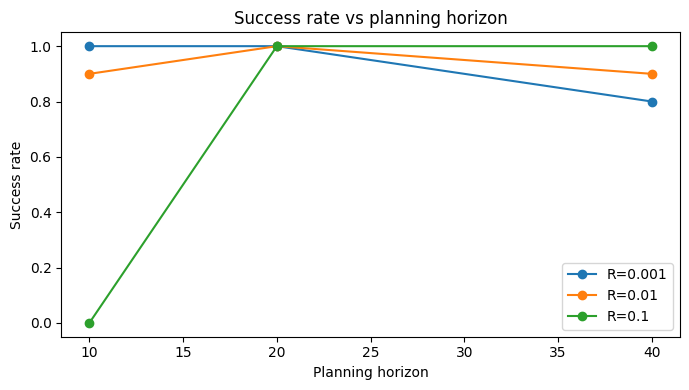

Saved: ../results/figures/success_rate.png


In [13]:
if len(summary_df) > 0:
    plt.figure(figsize=(7, 4))
    for penalty in sorted(summary_df["r_u"].unique()):
        sub = summary_df[summary_df["r_u"] == penalty].sort_values("horizon")
        plt.plot(sub["horizon"], sub["success_mean"], marker="o", label=f"R={penalty}")

    plt.xlabel("Planning horizon")
    plt.ylabel("Success rate")
    plt.title("Success rate vs planning horizon")
    plt.legend()
    plt.tight_layout()

    out = FIGURES_DIR / "success_rate.png"
    plt.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", out)


## 8. Plot final angle error vs planning horizon


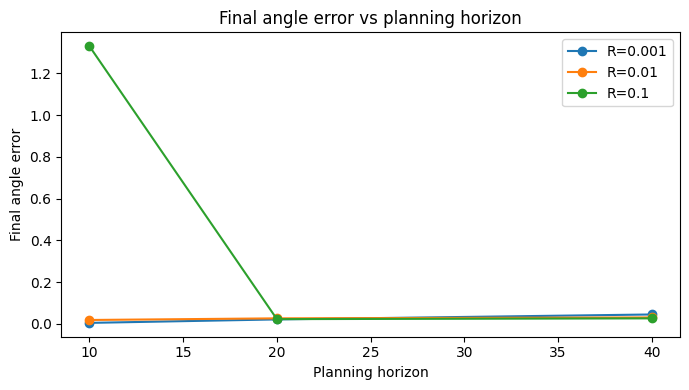

Saved: ../results/figures/final_angle_error.png


In [14]:
if len(summary_df) > 0:
    plt.figure(figsize=(7, 4))
    for penalty in sorted(summary_df["r_u"].unique()):
        sub = summary_df[summary_df["r_u"] == penalty].sort_values("horizon")
        plt.plot(sub["horizon"], sub["final_angle_error_mean"], marker="o", label=f"R={penalty}")

    plt.xlabel("Planning horizon")
    plt.ylabel("Final angle error")
    plt.title("Final angle error vs planning horizon")
    plt.legend()
    plt.tight_layout()

    out = FIGURES_DIR / "final_angle_error.png"
    plt.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", out)


## 9. Plot control effort vs penalty


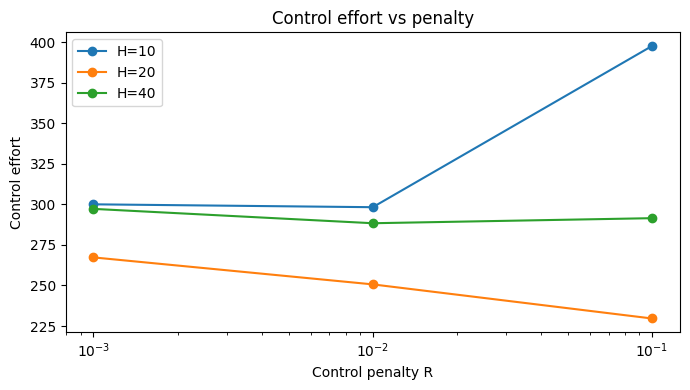

Saved: ../results/figures/control_effort.png


In [15]:
if len(summary_df) > 0:
    plt.figure(figsize=(7, 4))
    for horizon in sorted(summary_df["horizon"].unique()):
        sub = summary_df[summary_df["horizon"] == horizon].sort_values("r_u")
        plt.plot(sub["r_u"], sub["control_effort_mean"], marker="o", label=f"H={horizon}")

    plt.xscale("log")
    plt.xlabel("Control penalty R")
    plt.ylabel("Control effort")
    plt.title("Control effort vs penalty")
    plt.legend()
    plt.tight_layout()

    out = FIGURES_DIR / "control_effort.png"
    plt.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", out)


## 10. Load one trajectory example


In [16]:
TARGET_H = 40
TARGET_R = 0.1

match = None
for item in results:
    if item["summary"]["horizon"] == TARGET_H and item["summary"]["r_u"] == TARGET_R:
        match = item
        break

if match is None:
    print("Requested setting not found.")
else:
    print("Loaded:", match["filename"])
    print(match["summary"])


Loaded: h40_r0.1.json
{'success_mean': 1.0, 'success_std': 0.0, 'final_angle_error_mean': 0.026706547850056772, 'final_angle_error_std': 0.016977291738701956, 'control_effort_mean': 291.50391821851457, 'control_effort_std': 11.678234687548212, 'swingup_time_mean': 113.1, 'swingup_time_std': 11.596982366115766, 'mean_planning_cost_mean': 123.96285837187982, 'mean_planning_cost_std': 12.239739092101736, 'horizon': 40, 'r_u': 0.1}


## 11. Plot example angle, angular velocity, and torque


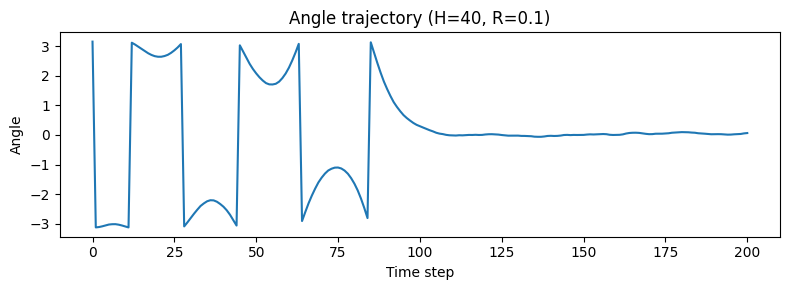

Saved: ../results/figures/example_trajectory_angle.png


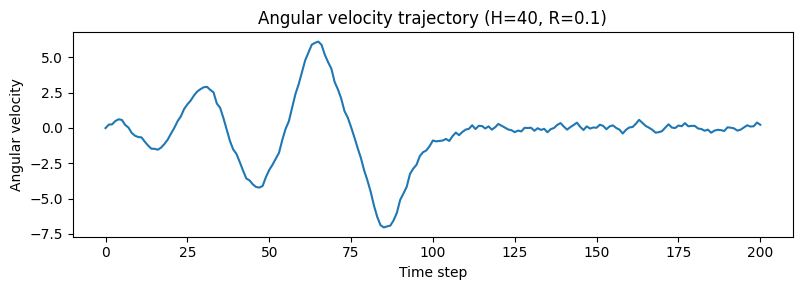

Saved: ../results/figures/example_trajectory_omega.png


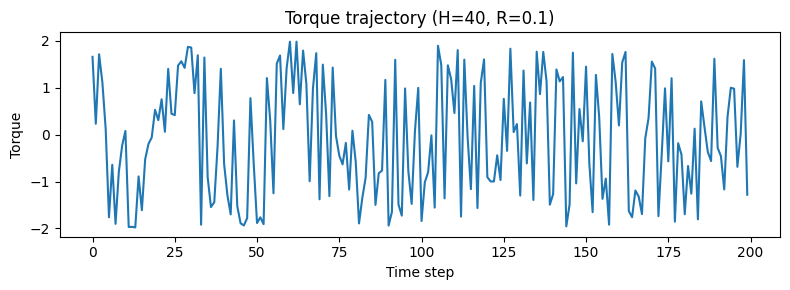

Saved: ../results/figures/example_trajectory_action.png


In [17]:
if match is not None:
    states = np.array(match["example_states"])
    actions = np.array(match["example_actions"])

    t_states = np.arange(len(states))
    t_actions = np.arange(len(actions))

    plt.figure(figsize=(8, 3))
    plt.plot(t_states, states[:, 0])
    plt.xlabel("Time step")
    plt.ylabel("Angle")
    plt.title(f"Angle trajectory (H={TARGET_H}, R={TARGET_R})")
    plt.tight_layout()
    out = FIGURES_DIR / "example_trajectory_angle.png"
    plt.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", out)

    plt.figure(figsize=(8, 3))
    plt.plot(t_states, states[:, 1])
    plt.xlabel("Time step")
    plt.ylabel("Angular velocity")
    plt.title(f"Angular velocity trajectory (H={TARGET_H}, R={TARGET_R})")
    plt.tight_layout()
    out = FIGURES_DIR / "example_trajectory_omega.png"
    plt.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", out)

    plt.figure(figsize=(8, 3))
    plt.plot(t_actions, actions)
    plt.xlabel("Time step")
    plt.ylabel("Torque")
    plt.title(f"Torque trajectory (H={TARGET_H}, R={TARGET_R})")
    plt.tight_layout()
    out = FIGURES_DIR / "example_trajectory_action.png"
    plt.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", out)


## 12. Per-seed metrics for selected setting


In [18]:
if match is not None:
    per_seed_df = pd.DataFrame(match["per_seed_metrics"])
    display(per_seed_df)


,success,final_angle_error,control_effort,swingup_time,mean_planning_cost
0,1,0.0617,310.9309,107,111.3491
1,1,0.0039,266.6047,100,114.8424
2,1,0.0485,279.8107,118,137.9875
3,1,0.0156,301.1460,125,137.7482
4,1,0.0135,295.9792,119,125.7630
5,1,0.0177,297.7109,112,122.3484
6,1,0.0316,284.5203,135,140.3397
7,1,0.0375,289.6496,97,105.7028
8,1,0.0200,292.1250,100,110.5480
9,1,0.0170,296.5619,118,132.9995


## 13. Create a mean ± std table for analysis


In [19]:
if len(summary_df) > 0:
    mean_std_table = summary_df[[
        "horizon", "r_u",
        "success_mean", "success_std",
        "final_angle_error_mean", "final_angle_error_std",
        "control_effort_mean", "control_effort_std"
    ]].copy()

    mean_std_table["success"] = mean_std_table.apply(
        lambda r: f"{r['success_mean']:.2f} ± {r['success_std']:.2f}", axis=1
    )
    mean_std_table["final_angle_error"] = mean_std_table.apply(
        lambda r: f"{r['final_angle_error_mean']:.4f} ± {r['final_angle_error_std']:.4f}", axis=1
    )
    mean_std_table["control_effort"] = mean_std_table.apply(
        lambda r: f"{r['control_effort_mean']:.2f} ± {r['control_effort_std']:.2f}", axis=1
    )

    mean_std_table = mean_std_table[["horizon", "r_u", "success", "final_angle_error", "control_effort"]]
    mean_std_table.columns = ["Horizon", "Penalty R", "Success Rate", "Final Angle Error", "Control Effort"]

    display(mean_std_table)


,Horizon,Penalty R,Success Rate,Final Angle Error,Control Effort
0,10,0.001,1.00 ± 0.00,0.0051 ± 0.0038,300.05 ± 29.14
1,10,0.010,0.90 ± 0.30,0.0190 ± 0.0077,298.27 ± 40.78
2,10,0.100,0.00 ± 0.00,1.3301 ± 0.6651,397.71 ± 20.55
3,20,0.001,1.00 ± 0.00,0.0217 ± 0.0129,267.31 ± 10.80
4,20,0.010,1.00 ± 0.00,0.0268 ± 0.0181,250.67 ± 9.93
5,20,0.100,1.00 ± 0.00,0.0230 ± 0.0190,229.63 ± 13.58
6,40,0.001,0.80 ± 0.40,0.0454 ± 0.0316,297.24 ± 12.23
7,40,0.010,0.90 ± 0.30,0.0312 ± 0.0252,288.38 ± 13.75
8,40,0.100,1.00 ± 0.00,0.0267 ± 0.0170,291.50 ± 11.68
